In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_excel('googleplaystore.xlsx')
pd.set_option('display.max_columns' , None) # used for displaying max columns
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


# Removing Duplicates and Cleaning the data

In [7]:
data.duplicated().sum()

np.int64(483)

In [3]:
data.drop_duplicates(inplace=True)

In [4]:
data.duplicated().sum()

np.int64(0)

In [5]:
data.isnull().sum()

App                  1
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

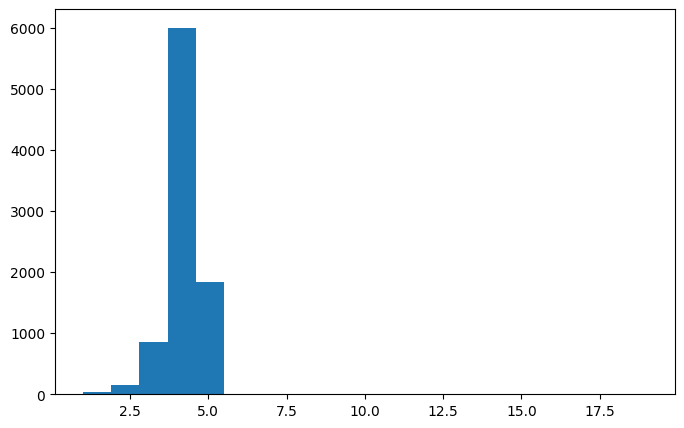

In [6]:
plt.figure(figsize=(8,5))
plt.hist(data['Rating'], bins=20)
plt.show()

In [11]:
median=data['Rating'].median()
median

np.float64(4.3)

In [12]:
data.fillna({'Rating' : median} , inplace=True)

In [13]:
data.isnull().sum()

App               1
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              1
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64

In [15]:
data.dropna(subset=['App' , 'Type' , 'Content Rating' , 'Current Ver' , 'Android Ver' ]  , inplace=True)

In [17]:
data.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10345 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10345 non-null  object 
 1   Category        10345 non-null  object 
 2   Rating          10345 non-null  float64
 3   Reviews         10345 non-null  object 
 4   Size            10345 non-null  object 
 5   Installs        10345 non-null  object 
 6   Type            10345 non-null  object 
 7   Price           10345 non-null  object 
 8   Content Rating  10345 non-null  object 
 9   Genres          10345 non-null  object 
 10  Last Updated    10345 non-null  object 
 11  Current Ver     10345 non-null  object 
 12  Android Ver     10345 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


# Changing the Data Types for proper Operations

In [20]:
data['Reviews']=data['Reviews'].astype(int)

In [27]:
data['Installs']=data['Installs'].str.replace('+' , '')

In [33]:
data['Installs']=data['Installs'].str.replace(',' , '')

In [35]:
data['Installs']=data['Installs'].astype(int)

In [37]:
data['Reviews']=data['Reviews'].astype(int)

In [40]:
data['Size']=data['Size'].str.replace('M' , '1000000')

In [53]:
data['Size']=data['Size'].str.replace('k' , '1000')

In [47]:
data['Size'] = data['Size'].replace('Varies with device', np.nan)


In [54]:
data['Size']=data['Size'].astype(float)

In [56]:
Med=data['Size'].median()

In [57]:
data.fillna({'Size' : Med } , inplace=True)

In [59]:
data['Price']=data['Price'].str.replace('$' , '')


In [68]:
data['Price'].isnull().sum()

np.int64(9583)

In [71]:
data.fillna({'Price' : 0} , inplace=True)

In [74]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1.910000e+08,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1.410000e+08,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.710000e+00,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2.510000e+08,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.810000e+00,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,5.310000e+08,5000,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.610000e+00,100,Free,0,Everyone,Education,"July 6, 2018",1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,4.3,3,9.510000e+00,1000,Free,0,Everyone,Medical,"January 20, 2017",1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,1.310000e+08,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [76]:
data['Price']=data['Price'].astype(float)

In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10345 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10345 non-null  object 
 1   Category        10345 non-null  object 
 2   Rating          10345 non-null  float64
 3   Reviews         10345 non-null  int64  
 4   Size            10345 non-null  float64
 5   Installs        10345 non-null  int64  
 6   Type            10345 non-null  object 
 7   Price           10345 non-null  float64
 8   Content Rating  10345 non-null  object 
 9   Genres          10345 non-null  object 
 10  Last Updated    10345 non-null  object 
 11  Current Ver     10345 non-null  object 
 12  Android Ver     10345 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.1+ MB


In [79]:
data['Last Updated'] = pd.to_datetime(data['Last Updated'])

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10345 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10345 non-null  object        
 1   Category        10345 non-null  object        
 2   Rating          10345 non-null  float64       
 3   Reviews         10345 non-null  int64         
 4   Size            10345 non-null  float64       
 5   Installs        10345 non-null  int64         
 6   Type            10345 non-null  object        
 7   Price           10345 non-null  float64       
 8   Content Rating  10345 non-null  object        
 9   Genres          10345 non-null  object        
 10  Last Updated    10345 non-null  datetime64[ns]
 11  Current Ver     10345 non-null  object        
 12  Android Ver     10345 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 1.1+ MB


In [81]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1.910000e+08,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1.410000e+08,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite â€“ FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.710000e+00,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2.510000e+08,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.810000e+00,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,5.310000e+08,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.610000e+00,100,Free,0.0,Everyone,Education,2018-07-06,1,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,4.3,3,9.510000e+00,1000,Free,0.0,Everyone,Medical,2017-01-20,1,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,1.310000e+08,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device


# Business Related Question

In [142]:
group1=data.groupby('Category')['App'].count().reset_index()

In [141]:
group1

,Category,App
0,ART_AND_DESIGN,64
1,AUTO_AND_VEHICLES,85
2,BEAUTY,53
3,BOOKS_AND_REFERENCE,229
4,BUSINESS,427
5,COMICS,59
6,COMMUNICATION,366
7,DATING,196
8,EDUCATION,130
9,ENTERTAINMENT,111


<BarContainer object of 33 artists>

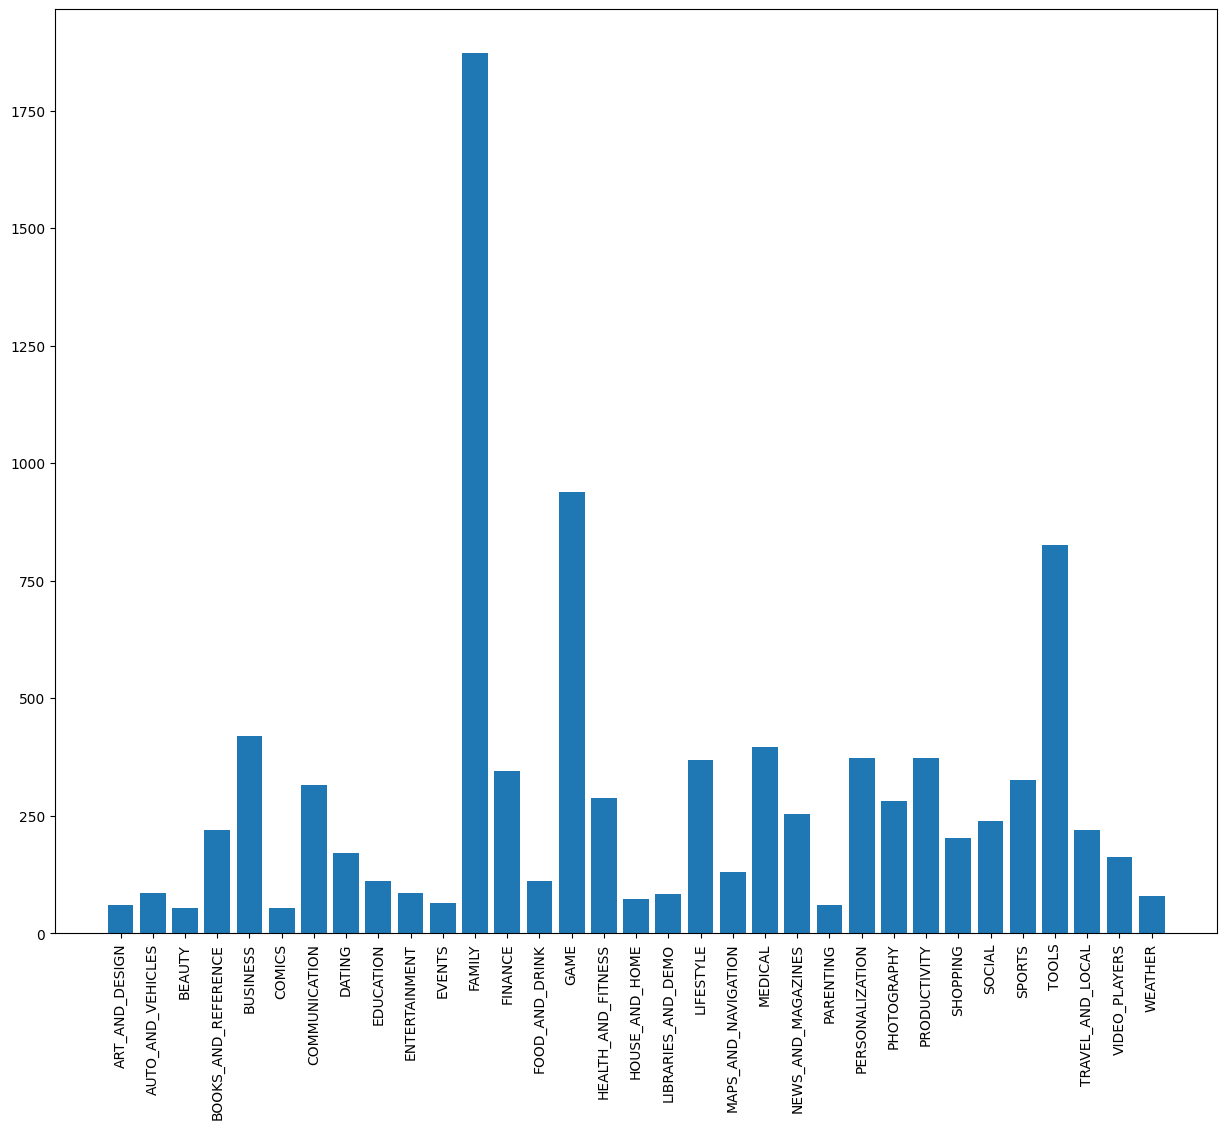

In [143]:
plt.figure(figsize=(15,12))
plt.xticks(rotation=90)
plt.bar(group1['Category'] , group1['App'])

In [110]:
group2=data.groupby('Type')['App'].count().reset_index()

In [144]:
group2

,Type,App
0,Free,9583
1,Paid,762


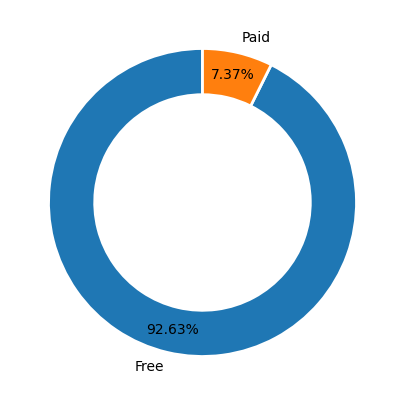

In [145]:
plt.figure(figsize=(9,5))

labels = ['Free' , 'Paid']
plt.pie(group2['App'],labels=labels,autopct='%1.2f%%' , startangle=90, pctdistance=0.85, wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2})


plt.show()

In [146]:
group3=data.groupby('Content Rating')['App'].count().reset_index()
group3

,Content Rating,App
0,Adults only 18+,3
1,Everyone,7893
2,Everyone 10+,321
3,Mature 17+,392
4,Teen,1036
5,Unrated,2


<BarContainer object of 6 artists>

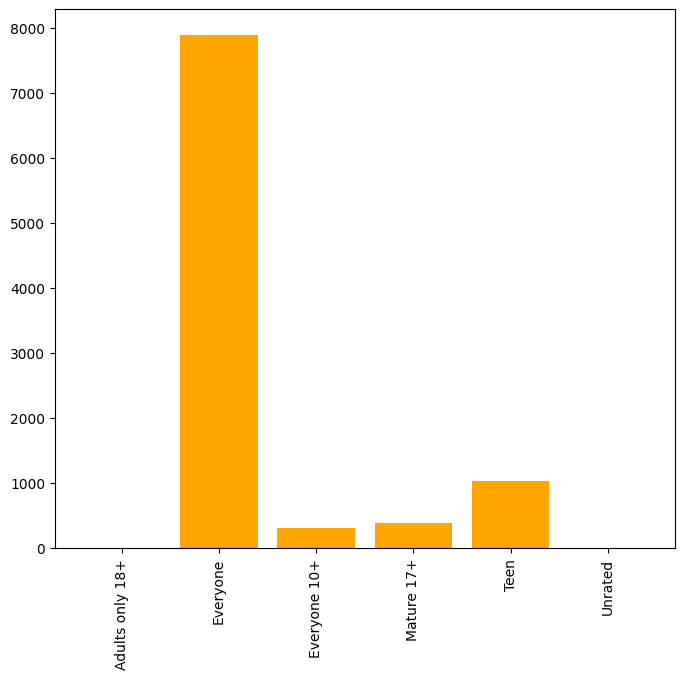

In [147]:
plt.figure(figsize=(8,7))
plt.xticks(rotation=90)
plt.bar(group3['Content Rating'] , group3['App'] , color='Orange')

# Top 10 most installed apps

In [148]:
group4=data.groupby('App')['Installs'].sum().reset_index()
group4.sort_values(by='Installs' , ascending=False ,  inplace=True)
group4

,App,Installs
9214,YouTube,1000000000
6157,Messenger â€“ Text and Video Chat for Free,1000000000
7835,Skype - free IM & video calls,1000000000
9030,WhatsApp Messenger,1000000000
8070,Subway Surfers,1000000000
...,...,...
579,Ain Arabic Kids Alif Ba ta,0
334,AP Series Solution Pro,0
4010,Eu Sou Rico,0
4011,Eu sou Rico,0


In [132]:
data.duplicated(subset=['App']).sum()

np.int64(698)

In [133]:
data.sort_values(by='Rating' , ascending=False , inplace=True)

In [134]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9701,EP Church Annapolis,LIFESTYLE,5.0,2,8.810000e+00,100,Free,0.00,Everyone,Lifestyle,2017-01-14,1,4.1 and up
9194,UP EB Bill Payment & Details,SOCIAL,5.0,3,2.410000e+00,50,Free,0.00,Teen,Social,2018-07-11,2,4.0 and up
9188,EB Scanner,PRODUCTIVITY,5.0,9,2.510000e+08,50,Free,0.00,Everyone,Productivity,2018-02-11,1.7.8,4.0.3 and up
9178,i am EB,PHOTOGRAPHY,5.0,1,5.410000e+00,10,Free,0.00,Teen,Photography,2017-02-01,1,4.1 and up
5237,Hey AJ! It's Saturday!,BOOKS_AND_REFERENCE,5.0,12,5.010000e+08,100,Paid,3.99,Everyone,Books & Reference,2016-06-13,1.0.0,2.2 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7427,CJ DVD Rentals,COMMUNICATION,1.0,5,1.310000e+08,100,Free,0.00,Everyone,Communication,2017-10-06,1,4.1 and up
8820,DS Creator 2.0,TOOLS,1.0,2,4.410000e+00,500,Free,0.00,Everyone,Tools,2018-03-23,2.0.180226.1,4.0 and up
10400,Familial Hypercholesterolaemia Handbook,MEDICAL,1.0,2,3.310000e+08,100,Free,0.00,Everyone,Medical,2018-07-02,2.0.1,4.1 and up
6319,BJ Bridge Standard American 2018,GAME,1.0,1,4.910000e+00,1000,Free,0.00,Everyone,Card,2018-05-21,6.2-sayc,4.0 and up


In [136]:
data.drop_duplicates(subset=['App'] , inplace=True)

In [137]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9647 entries, 9701 to 8875
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9647 non-null   object        
 1   Category        9647 non-null   object        
 2   Rating          9647 non-null   float64       
 3   Reviews         9647 non-null   int64         
 4   Size            9647 non-null   float64       
 5   Installs        9647 non-null   int64         
 6   Type            9647 non-null   object        
 7   Price           9647 non-null   float64       
 8   Content Rating  9647 non-null   object        
 9   Genres          9647 non-null   object        
 10  Last Updated    9647 non-null   datetime64[ns]
 11  Current Ver     9647 non-null   object        
 12  Android Ver     9647 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory usage: 1.0+ MB


In [138]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9701,EP Church Annapolis,LIFESTYLE,5.0,2,8.810000e+00,100,Free,0.00,Everyone,Lifestyle,2017-01-14,1,4.1 and up
9194,UP EB Bill Payment & Details,SOCIAL,5.0,3,2.410000e+00,50,Free,0.00,Teen,Social,2018-07-11,2,4.0 and up
9188,EB Scanner,PRODUCTIVITY,5.0,9,2.510000e+08,50,Free,0.00,Everyone,Productivity,2018-02-11,1.7.8,4.0.3 and up
9178,i am EB,PHOTOGRAPHY,5.0,1,5.410000e+00,10,Free,0.00,Teen,Photography,2017-02-01,1,4.1 and up
5237,Hey AJ! It's Saturday!,BOOKS_AND_REFERENCE,5.0,12,5.010000e+08,100,Paid,3.99,Everyone,Books & Reference,2016-06-13,1.0.0,2.2 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7427,CJ DVD Rentals,COMMUNICATION,1.0,5,1.310000e+08,100,Free,0.00,Everyone,Communication,2017-10-06,1,4.1 and up
8820,DS Creator 2.0,TOOLS,1.0,2,4.410000e+00,500,Free,0.00,Everyone,Tools,2018-03-23,2.0.180226.1,4.0 and up
10400,Familial Hypercholesterolaemia Handbook,MEDICAL,1.0,2,3.310000e+08,100,Free,0.00,Everyone,Medical,2018-07-02,2.0.1,4.1 and up
6319,BJ Bridge Standard American 2018,GAME,1.0,1,4.910000e+00,1000,Free,0.00,Everyone,Card,2018-05-21,6.2-sayc,4.0 and up


In [140]:
data.duplicated(subset=['App']).sum()

np.int64(0)

In [149]:
data.reset_index(drop=True, inplace=True)

In [150]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,EP Church Annapolis,LIFESTYLE,5.0,2,8.810000e+00,100,Free,0.00,Everyone,Lifestyle,2017-01-14,1,4.1 and up
1,UP EB Bill Payment & Details,SOCIAL,5.0,3,2.410000e+00,50,Free,0.00,Teen,Social,2018-07-11,2,4.0 and up
2,EB Scanner,PRODUCTIVITY,5.0,9,2.510000e+08,50,Free,0.00,Everyone,Productivity,2018-02-11,1.7.8,4.0.3 and up
3,i am EB,PHOTOGRAPHY,5.0,1,5.410000e+00,10,Free,0.00,Teen,Photography,2017-02-01,1,4.1 and up
4,Hey AJ! It's Saturday!,BOOKS_AND_REFERENCE,5.0,12,5.010000e+08,100,Paid,3.99,Everyone,Books & Reference,2016-06-13,1.0.0,2.2 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9642,CJ DVD Rentals,COMMUNICATION,1.0,5,1.310000e+08,100,Free,0.00,Everyone,Communication,2017-10-06,1,4.1 and up
9643,DS Creator 2.0,TOOLS,1.0,2,4.410000e+00,500,Free,0.00,Everyone,Tools,2018-03-23,2.0.180226.1,4.0 and up
9644,Familial Hypercholesterolaemia Handbook,MEDICAL,1.0,2,3.310000e+08,100,Free,0.00,Everyone,Medical,2018-07-02,2.0.1,4.1 and up
9645,BJ Bridge Standard American 2018,GAME,1.0,1,4.910000e+00,1000,Free,0.00,Everyone,Card,2018-05-21,6.2-sayc,4.0 and up
